# Kahupuke Data Exploratory Analysis

The Kahupuke Data is a comprehensive collection designed for 
exploring the intersections between Hawaiian and English 
languages through literature. This dataset includes over 295 
books, each offering insights into language usage, cultural 
context, and linguistic evolution.

In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
from pathlib import Path
from PIL import Image

# Data Overview

In [2]:
# Path to the utils directory containing text_utils.py
UTIL_DIR = os.path.abspath("../src/utils")
if UTIL_DIR not in sys.path:
    sys.path.append(UTIL_DIR)
from text_utils import InternalState

api = InternalState()
book_list = api.get_book_list()
book_covers = api.get_book_cover_paths()

In [3]:
df = pd.DataFrame(book_list)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      295 non-null    object
 1   author     295 non-null    object
 2   language   295 non-null    object
 3   subject    295 non-null    object
 4   publisher  295 non-null    object
 5   type       295 non-null    object
 6   category   295 non-null    object
 7   id         295 non-null    object
 8   url        295 non-null    object
 9   img        295 non-null    object
dtypes: object(10)
memory usage: 23.2+ KB


In [4]:
df.head(5)

,title,author,language,subject,publisher,type,category,id,url,img
0,A collection of historical accounts and oral h...,Kepā Ma,en,"Hawaiians, Kona (Hawaii Island, Hawai",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY5,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY5.jpg
1,"A collection of traditions, historical account...",Kepā Ma,en,"Hawaiians, Kaluanui (Hawaii), Hawa",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY8,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY8.jpg
2,A day with Makana (I kekahi lā me Makana),Kaylene Kauwila Sheld,haw,,Nā Kamalei-Koʻolau Early Education Progr,Non-Fiction,Beginner,EBOOK-MAKANA,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MAKANA.jpg
3,A dictionary of Hawaiian legal land-terms,Paul F. Nahoa Luc,en,"Real property, Conveyancing, Land titles, Vend...",Native Hawaiian Legal Corp. :|University of Ha...,Non-Fiction,General,EBOOK-DHLLT,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-D...,/cover_img/EBOOK-DHLLT.jpg
4,A dictionary of the Hawaiian language (revised...,Lorrin Andre,en,Hawaiian langua,Published by the Boa,Non-Fiction,Reference,EBOOK-PARKER,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-P...,/cover_img/EBOOK-PARKER.jpg


In [5]:
df.describe()

,title,author,language,subject,publisher,type,category,id,url,img
count,295,295,295,295,295,295,295,295,295,295
unique,294,156,3,208,114,2,4,295,295,295
top,"Project Kāhea Loko, ""The call of the pond""",Kepā Ma,haw,,Hale Kuamo,Non-Fiction,General,EBOOK-MALY5,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/cover_img/EBOOK-MALY5.jpg
freq,2,18,161,21,30,255,123,1,1,1


In [6]:
# Get the amount of books
print(f"Total number of books: {len(df)}")

Total number of books: 295


In [7]:
# We did a simple patch to replace 'Ōlelo Hawaiʻi' with 'haw' for consistency
language_mapping = {'Ōlelo Hawaiʻi':
'haw'}

# Apply the mapping to the 'language' column
df['language'] = df['language'].replace(language_mapping)
language_counts = df['language'].value_counts()
language_counts

language
haw    162
en     133
Name: count, dtype: int64

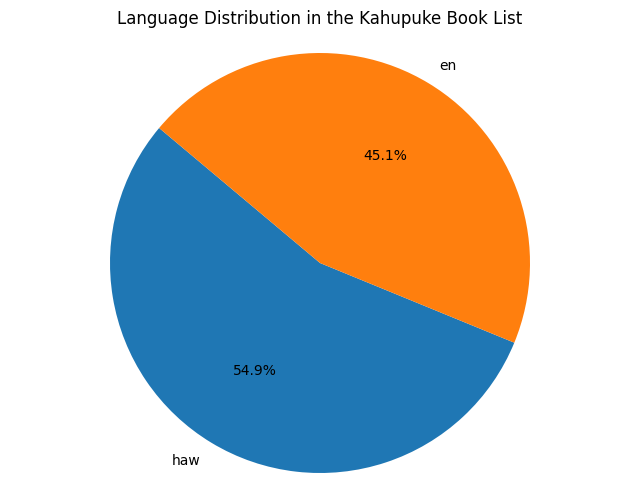

In [8]:
# Count the occurrences of each language
language_counts = df['language'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(language_counts,
labels=language_counts.index,
autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Language Distribution in the Kahupuke Book List')
plt.show()

# Book Images Review

In [9]:
df['img'] = df['id'].map(book_covers).fillna(df['img'])

def show_book_grid(df, n=5, figsize=10):
    """
    Display an n×n grid of book-cover images sampled at random from df['img'].

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain an 'img' column storing absolute cover-image paths.
    n : int, default 5
        Grid dimension → n rows × n columns (n² covers total).
    figsize : int or float, default 10
        Square figure size passed to plt.subplots().
    """
    total = n * n
    if len(df) < total:
        raise ValueError(f"need {total} rows, but df only has {len(df)}")

    paths = df["img"].sample(total, random_state=None).tolist()

    fig, axes = plt.subplots(n, n, figsize=(figsize, figsize))

    for ax, path in zip(axes.flat, paths):
        try:
            img = Image.open(Path(path))
            ax.imshow(img)
            ax.axis("off")
        except Exception as err:
            # fallback placeholder
            ax.text(0.5, 0.5, "image\nmissing", ha="center", va="center",
                    fontsize=8, wrap=True)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


In [10]:
df

,title,author,language,subject,publisher,type,category,id,url,img
0,A collection of historical accounts and oral h...,Kepā Ma,en,"Hawaiians, Kona (Hawaii Island, Hawai",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY5,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/data2/kahupuke/images/EBOOK-MALY5/2.5.8.jpg
1,"A collection of traditions, historical account...",Kepā Ma,en,"Hawaiians, Kaluanui (Hawaii), Hawa",Kumu Pono Associat,Non-Fiction,General,EBOOK-MALY8,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/data2/kahupuke/images/EBOOK-MALY8/2.9.34.jpg
2,A day with Makana (I kekahi lā me Makana),Kaylene Kauwila Sheld,haw,,Nā Kamalei-Koʻolau Early Education Progr,Non-Fiction,Beginner,EBOOK-MAKANA,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-M...,/data2/kahupuke/images/EBOOK-MAKANA/2.3.3.jpg
3,A dictionary of Hawaiian legal land-terms,Paul F. Nahoa Luc,en,"Real property, Conveyancing, Land titles, Vend...",Native Hawaiian Legal Corp. :|University of Ha...,Non-Fiction,General,EBOOK-DHLLT,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-D...,/data2/kahupuke/images/EBOOK-DHLLT/2.7.16.jpg
4,A dictionary of the Hawaiian language (revised...,Lorrin Andre,en,Hawaiian langua,Published by the Boa,Non-Fiction,Reference,EBOOK-PARKER,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-P...,/data2/kahupuke/images/EBOOK-PARKER/2.9.34.jpg
...,...,...,...,...,...,...,...,...,...,...
290,ʻO Waimānalo: koʻu wahi noho (Waimānalo: where...,Julie Stewart Willia,haw,Waimanalo (Hawai,Hale Paʻi o nā Kula ʻo Kamehame,Non-Fiction,Beginner,EBOOK-HSI3,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-H...,/data2/kahupuke/images/EBOOK-HSI3/2.3.24.jpg
291,ʻO Waiʻanae: koʻu wahi noho (Waiʻanae: where I...,Julie Stewart Willia,haw,"Waianae (Hawaii), Hawa",Hale Paʻi o nā Kula ʻo Kamehame,Non-Fiction,Beginner,EBOOK-HSI2,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-H...,/data2/kahupuke/images/EBOOK-HSI2/2.3.27.jpg
292,ʻŌiwi Vol. 1 (1998),Kuleana ʻŌiwi Pre,en,"Hawaiian literature, American literature, Auth...",Kuleana ʻŌiwi Pre,Non-Fiction,General,EBOOK-OIWI1,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-O...,/data2/kahupuke/images/EBOOK-OIWI1/2.26.6.jpg
293,ʻŌiwi Vol. 2 (2002),Kuleana ʻŌiwi Pre,en,"Hawaiian literature, American literature, Auth...",Kuleana ʻŌiwi Pre,Non-Fiction,General,EBOOK-OIWI2,https://ulukau.org/ulukau-books/?a=d&d=EBOOK-O...,/data2/kahupuke/images/EBOOK-OIWI2/2.26.6.jpg


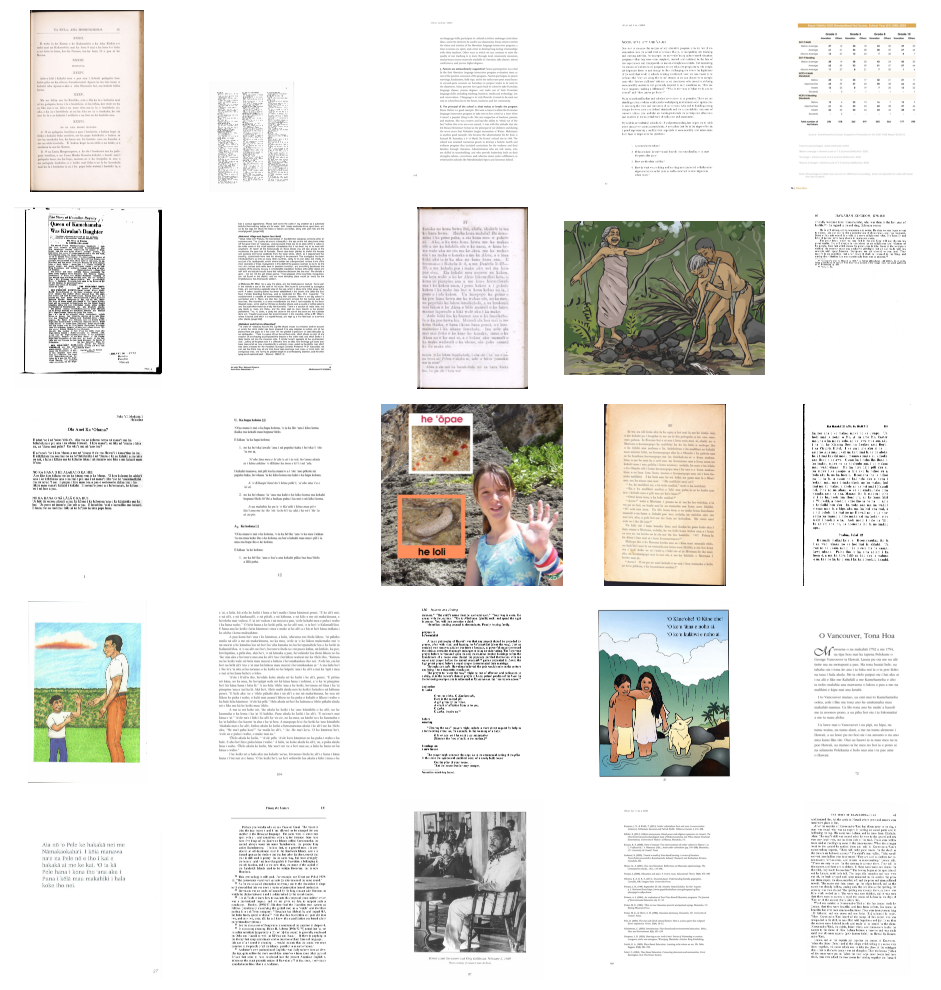

In [11]:
show_book_grid(df)

## Enhanced Visualization: Language Distribution
The following bar plot uses Seaborn to show the distribution of languages in the Kahupuke book list. This format is clear, professional, and suitable for technical presentations. Counts are annotated for clarity.

/tmp/ipykernel_409125/1093318718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='language', palette='viridis')


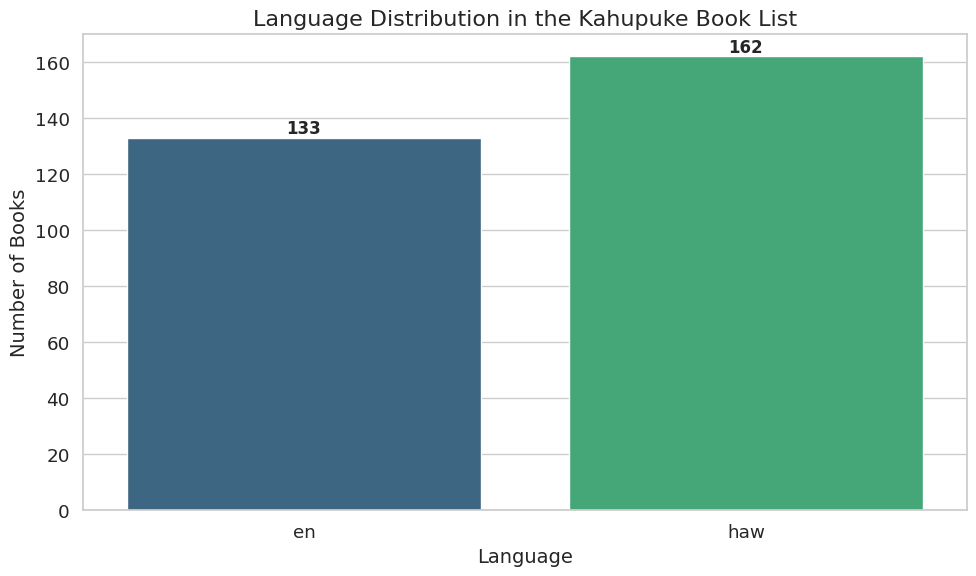

In [12]:
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.2)  # Professional style for presentations
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='language', palette='viridis')
plt.title('Language Distribution in the Kahupuke Book List', fontsize=16)
plt.xlabel('Language', fontsize=14)
plt.ylabel('Number of Books', fontsize=14)

# Annotate counts on bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

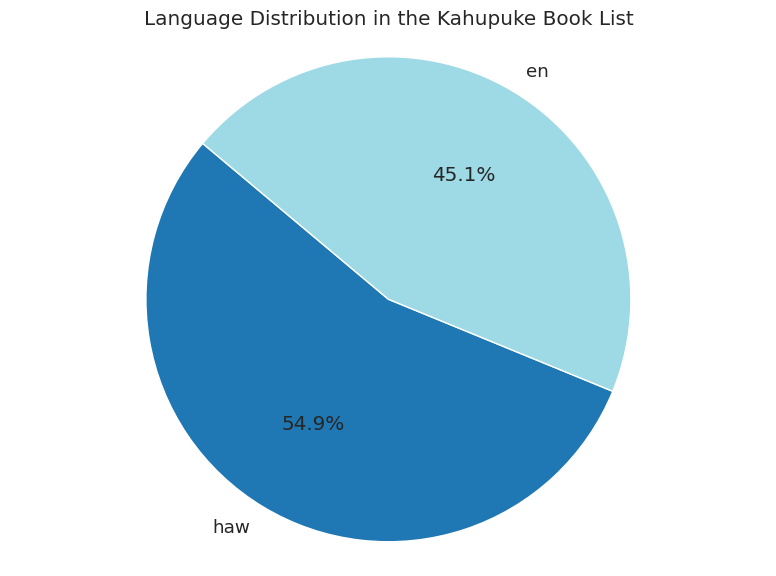

In [13]:
import numpy as np
from matplotlib import cm
contrast_colors = cm.tab20(np.linspace(0, 1, len(df['language'].value_counts())))
plt.figure(figsize=(8, 6))
plt.pie(df['language'].value_counts(),
        labels=df['language'].value_counts().index,
        autopct='%1.1f%%', startangle=140,
        colors=contrast_colors)
plt.axis('equal')
plt.title('Language Distribution in the Kahupuke Book List')
plt.tight_layout()
plt.show()

## EDA for Hawaiian Language Model Training
To inform the development of a Hawaiian language encoder model, we explore key dataset characteristics:
- **Book Count by Language**: Indicates available data for each language.
- **Estimated Word Count by Language**: Shows corpus size for model training.
- **Distribution of Book Lengths**: Highlights variability and richness of text sources.
These analyses help assess data sufficiency and guide preprocessing for effective model training.

/tmp/ipykernel_409125/3232486144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='language', palette='tab20')


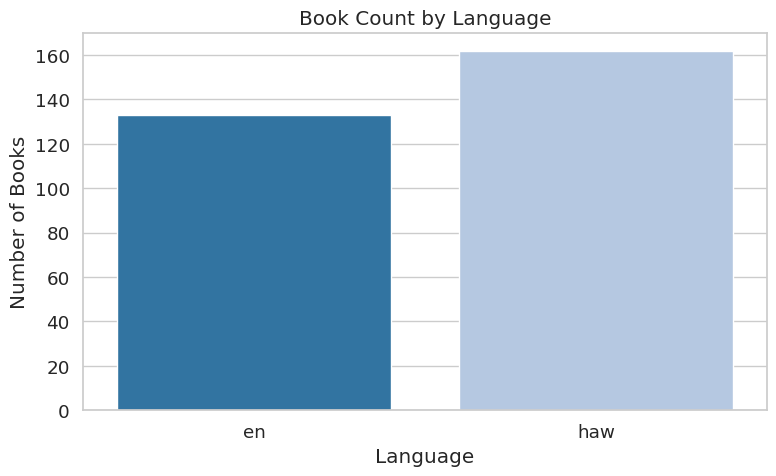

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='language', palette='tab20')
plt.title('Book Count by Language')
plt.xlabel('Language')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.show()

In [15]:
# Estimate word count per book if not present; adjust if you have a 'word_count' column
if 'word_count' in df.columns:
    word_counts = df.groupby('language')['word_count'].sum()
else:
    # Estimate from page count if available, assuming ~300 words per page
    if 'pages' in df.columns:
        df['estimated_word_count'] = df['pages'] * 300
        word_counts = df.groupby('language')['estimated_word_count'].sum()
    else:
        word_counts = None
if word_counts is not None:
    plt.figure(figsize=(8, 5))
    word_counts.plot(kind='bar', color=sns.color_palette('tab20'))
    plt.title('Estimated Word Count by Language')
    plt.xlabel('Language')
    plt.ylabel('Total Word Count')
    plt.tight_layout()
    plt.show()
else:
    print('No word or page count data available for estimation.')

No word or page count data available for estimation.


In [16]:
# Visualize distribution of book lengths by language
if 'word_count' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='language', y='word_count', palette='tab20')
    plt.title('Distribution of Book Word Counts by Language')
    plt.xlabel('Language')
    plt.ylabel('Word Count')
    plt.tight_layout()
    plt.show()
elif 'pages' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='language', y='pages', palette='tab20')
    plt.title('Distribution of Book Page Counts by Language')
    plt.xlabel('Language')
    plt.ylabel('Page Count')
    plt.tight_layout()
    plt.show()
else:
    print('No word count or page count data available for visualization.')

No word count or page count data available for visualization.


/tmp/ipykernel_409125/2399313153.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='type', palette='tab20', order=df['type'].value_counts().index)


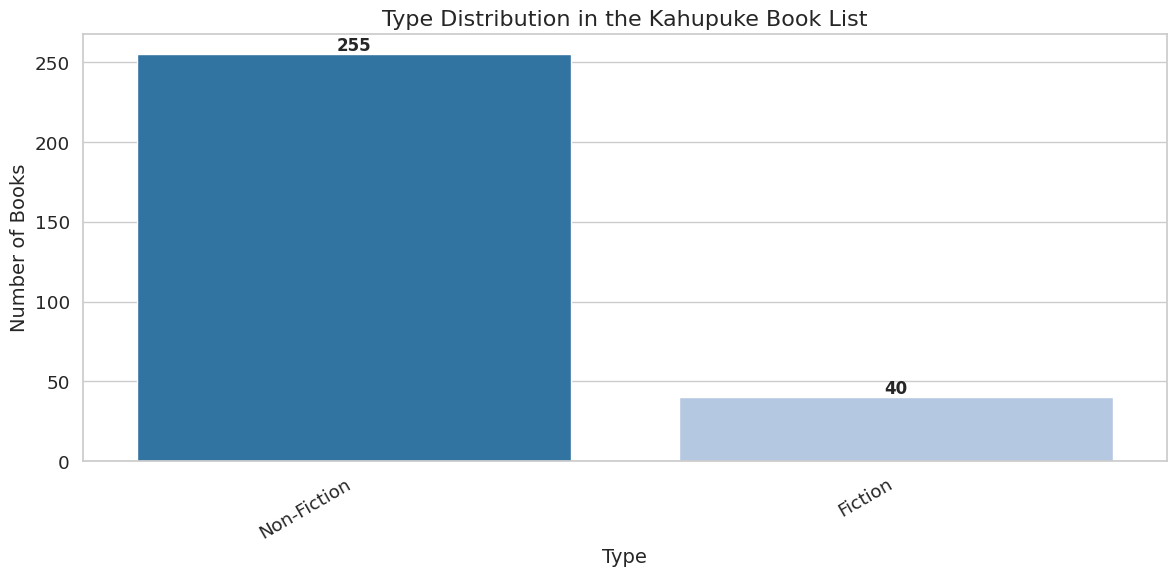

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of book types
if 'type' in df.columns and df['type'].notnull().any():
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid", font_scale=1.2)
    ax = sns.countplot(data=df, x='type', palette='tab20', order=df['type'].value_counts().index)
    plt.title('Type Distribution in the Kahupuke Book List', fontsize=16)
    plt.xlabel('Type', fontsize=14)
    plt.ylabel('Number of Books', fontsize=14)
    plt.xticks(rotation=30, ha='right')
    # Annotate counts on bars
    for p in ax.patches:
        count = int(p.get_height())
        ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2, count),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No type information available in the dataset.')

Total unique authors: 156
Books per author (top 10):
author
Kepā Ma                                                                    18
Kamehameha Schoo                                                            16
Julie Stewart Willia                                                        14
No Author Fou                                                               11
Liana Iaea Hon                                                              11
Mary Kawena Puk                                                              7
Kawehilani Aveli                                                             7
Hawaii Office of Library Services, Library of Hawaii, Hawaii State Libra     6
William H. Wils                                                              6
Lorrin Andre                                                                 5
Name: count, dtype: int64


/tmp/ipykernel_409125/940486046.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=author_counts.index[:top_n], y=author_counts.values[:top_n], palette='tab20')


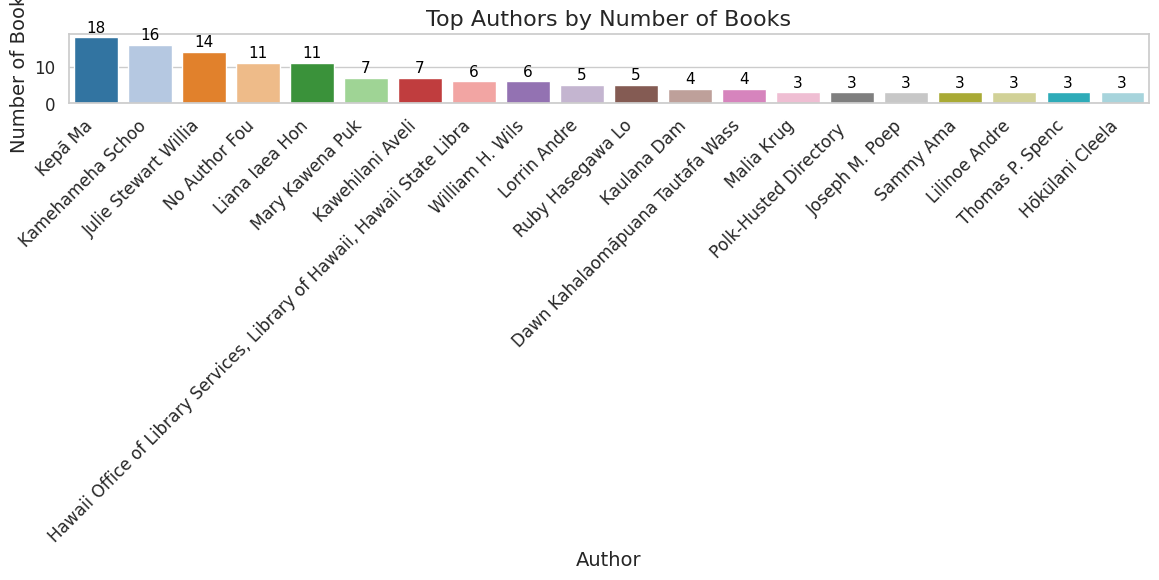

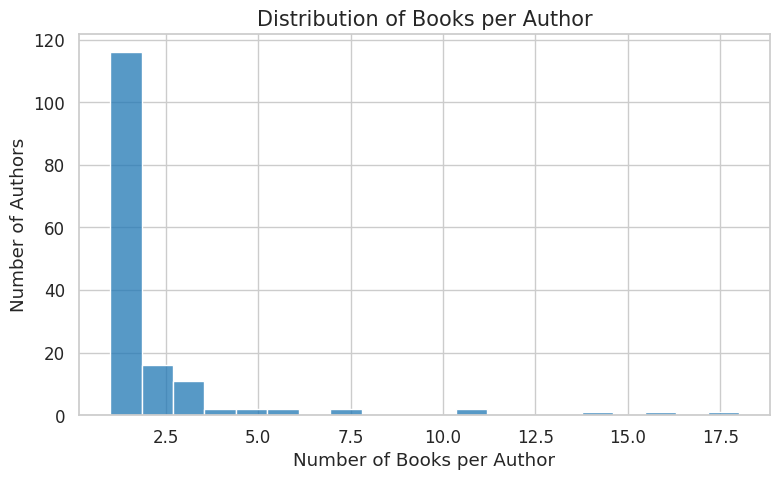

Summary statistics for books per author:
count    156.000000
mean       1.891026
std        2.528735
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       18.000000
Name: count, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Analyze authorship in the dataset
if 'author' in df.columns and df['author'].notnull().any():
    # Count unique authors
    unique_authors = df['author'].nunique()
    print(f'Total unique authors: {unique_authors}')

    # Count books per author
    author_counts = df['author'].value_counts()
    print(f'Books per author (top 10):\n{author_counts.head(10)}')

    # Visualize distribution of books per author (top 20 for clarity)
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid", font_scale=1.1)
    top_n = 20 if len(author_counts) > 20 else len(author_counts)
    ax = sns.barplot(x=author_counts.index[:top_n], y=author_counts.values[:top_n], palette='tab20')
    plt.title('Top Authors by Number of Books', fontsize=16)
    plt.xlabel('Author', fontsize=14)
    plt.ylabel('Number of Books', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(author_counts.values[:top_n]):
        ax.text(i, v + 0.5, str(v), color='black', ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print('Summary statistics for books per author:')
    print(author_counts.describe())
else:
    print('No author information available in the dataset.')